In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

### Task 1: Data and Tokenizer Understanding

In [ ]:
dataset = load_dataset("ag_news", split="train[:500]")

class SimpleTokenizer:
    def __init__(self):
        self.vocab = {"<PAD>": 0, "<UNK>": 1}
        self.id2word = {0: "<PAD>", 1: "<UNK>"}

    def fit(self, texts):
        for text in texts:
            words = text.lower().replace('.', ' . ').replace(',', ' , ').split()
            for word in words:
                if word not in self.vocab:
                    idx = len(self.vocab)
                    self.vocab[word] = idx
                    self.id2word[idx] = word

    def encode(self, text, max_len=32):
        words = text.lower().replace('.', ' . ').replace(',', ' , ').split()
        tokens = [self.vocab.get(w, self.vocab["<UNK>"]) for w in words]
        if len(tokens) > max_len:
            tokens = tokens[:max_len]
        else:
            tokens = tokens + [self.vocab["<PAD>"]] * (max_len - len(tokens))
        return tokens

tokenizer = SimpleTokenizer()
texts = dataset['text']
labels = dataset['label']
tokenizer.fit(texts)

print(f"Vocabulary Size: {len(tokenizer.vocab)}")

# Prepare dataset
max_len = 32
X = torch.tensor([tokenizer.encode(t, max_len) for t in texts], dtype=torch.long)
Y = torch.tensor(labels, dtype=torch.long)

classes = ['World', 'Sports', 'Business', 'Sci/Tech']
print("Label distribution:", {classes[i]: labels.count(i) for i in set(labels)})


### Task 2: Implement Transformer Elements

In [ ]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k, use_scaling=True):
        super().__init__()
        self.d_k = d_k
        self.use_scaling = use_scaling

    def forward(self, q, k, v, mask=None):
        # q, k, v shape: (batch_size, heads, seq_len, d_k)
        scores = torch.matmul(q, k.transpose(-2, -1))
        if self.use_scaling:
            scores = scores / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attn_weights, v)
        return output, attn_weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, use_scaling=True):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention(self.d_k, use_scaling=use_scaling)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        q = self.W_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k = self.W_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = self.W_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        attn_output, attn_weights = self.attention(q, k, v, mask)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        output = self.W_o(attn_output)
        return output, attn_weights

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff=256, dropout=0.1, use_scaling=True):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads, use_scaling=use_scaling)
        self.norm1 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out, attn_weights = self.mha(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))

        ff_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x, attn_weights

class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_classes, max_len=32, use_pe=True, use_scaling=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.use_pe = use_pe
        if use_pe:
            self.pos_encoder = PositionalEncoding(d_model, max_len)
        self.encoder_block = TransformerBlock(d_model, num_heads, use_scaling=use_scaling)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x, mask=None):
        x = self.embedding(x)
        if self.use_pe:
            x = self.pos_encoder(x)
        x, attn_weights = self.encoder_block(x, mask)

        # Mean pooling
        pooled_out = x.mean(dim=1)
        logits = self.fc(pooled_out)

        return logits, attn_weights


### Task 2: Training the Encoder

Training started...
Epoch 5/15 - Loss: 0.5381
Epoch 10/15 - Loss: 0.0259
Epoch 15/15 - Loss: 0.0036


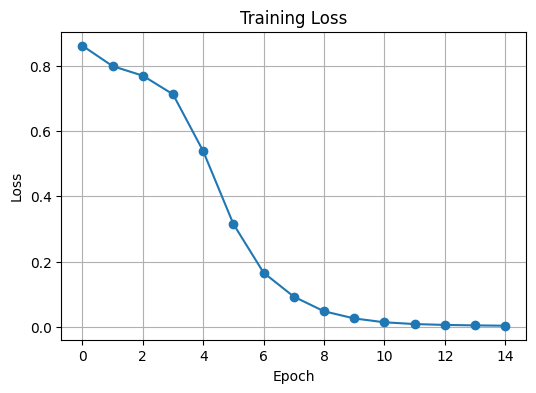

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

dataset_loader = DataLoader(TensorDataset(X, Y), batch_size=16, shuffle=True)

vocab_size = len(tokenizer.vocab)
d_model = 64
num_heads = 4
num_classes = 4

model = TransformerEncoder(vocab_size, d_model, num_heads, num_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 15
losses = []

model.train()
print("Training started...")
for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, batch_y in dataset_loader:
        optimizer.zero_grad()

        logits, _ = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(dataset_loader)
    losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), "transformer_model.pt")

plt.figure(figsize=(6, 4))
plt.plot(losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


### Task 3 & 4: Attention Heatmaps & Head Comparison

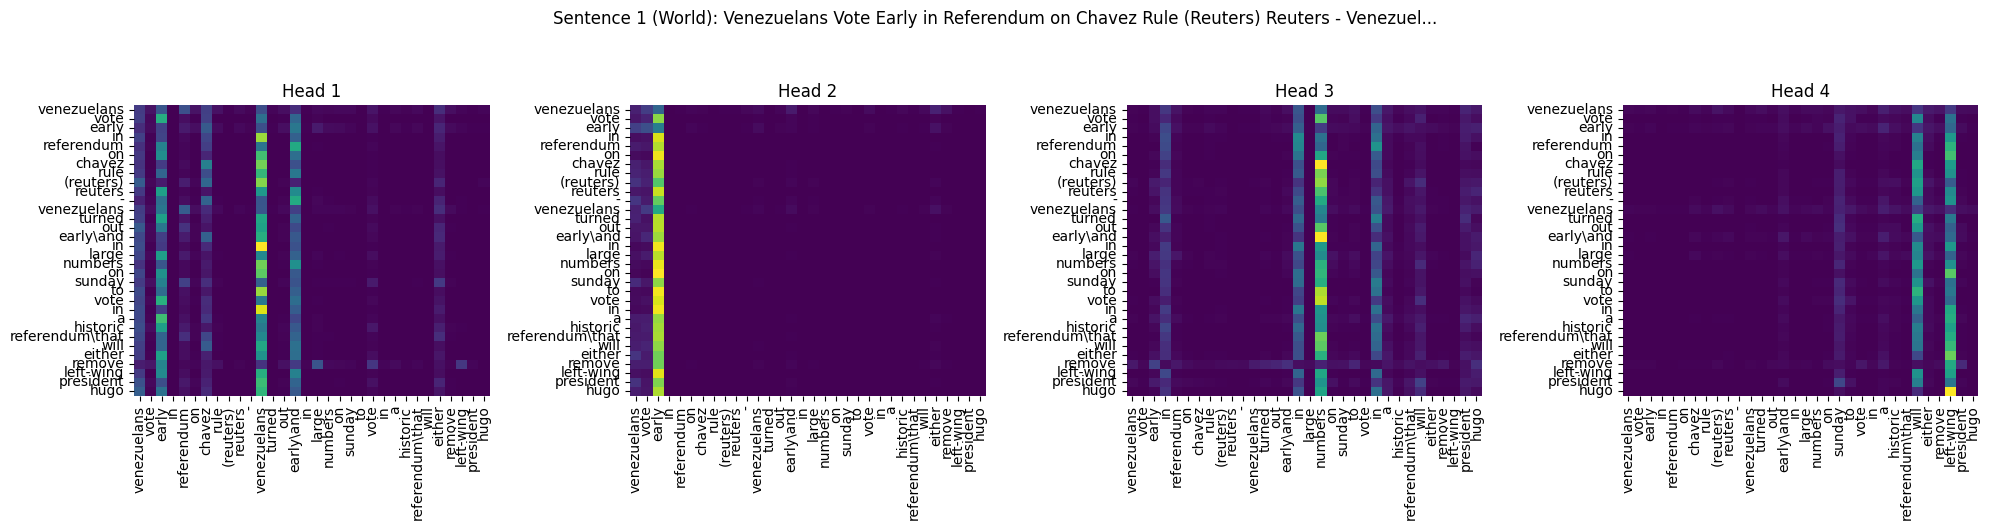

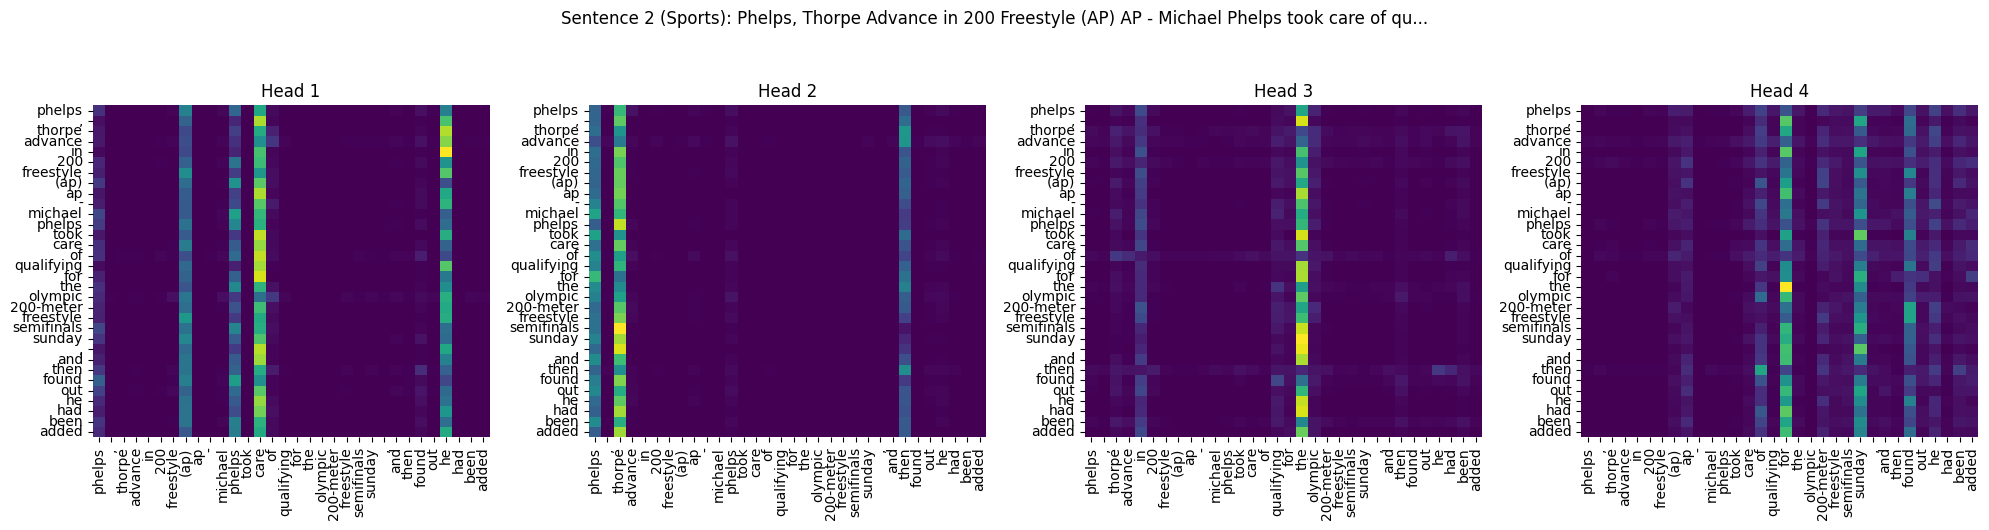

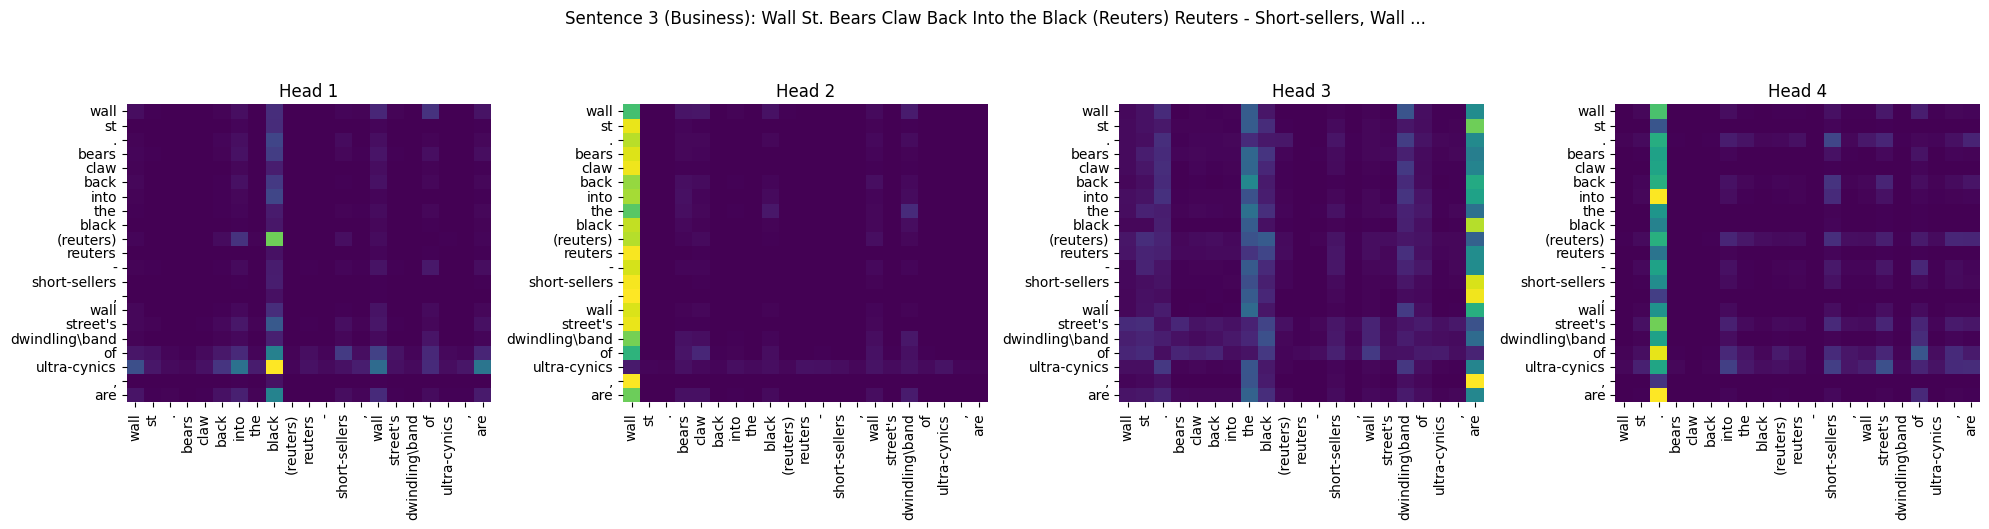

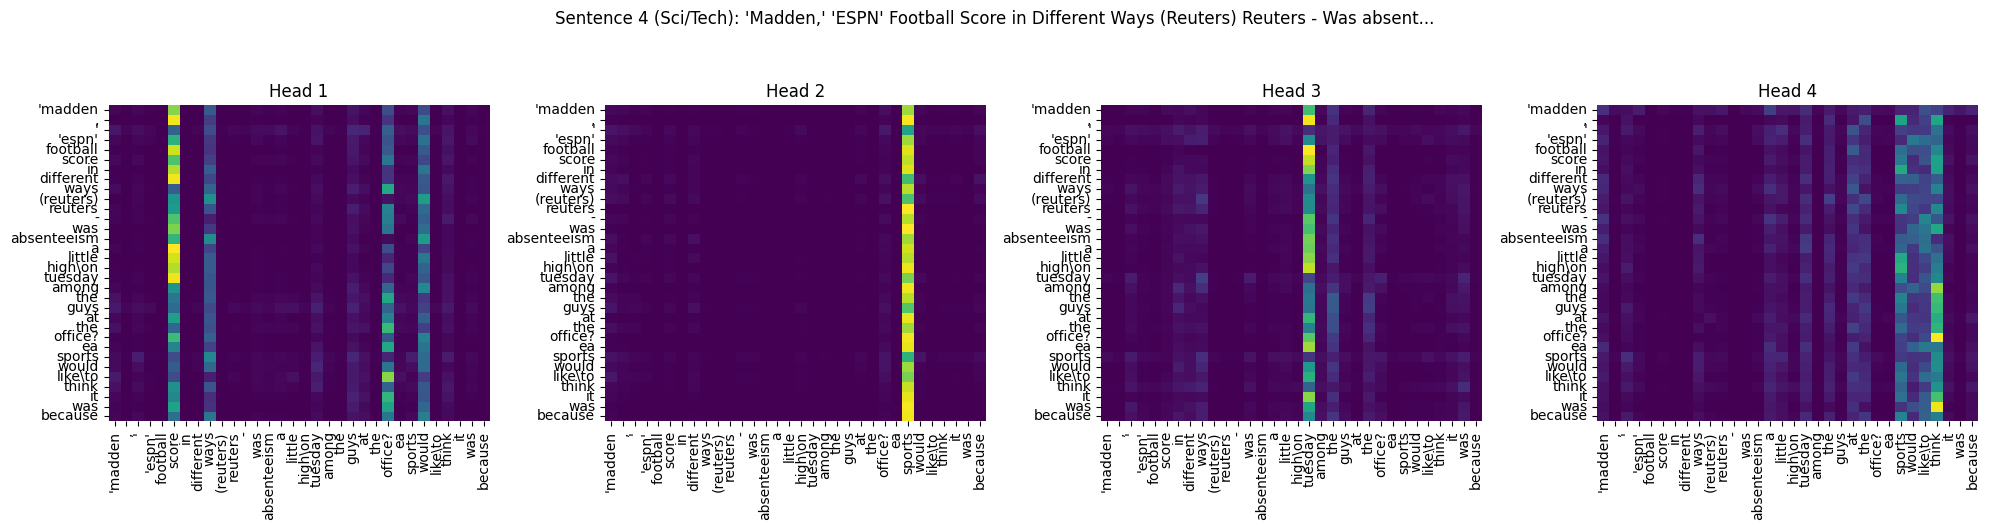

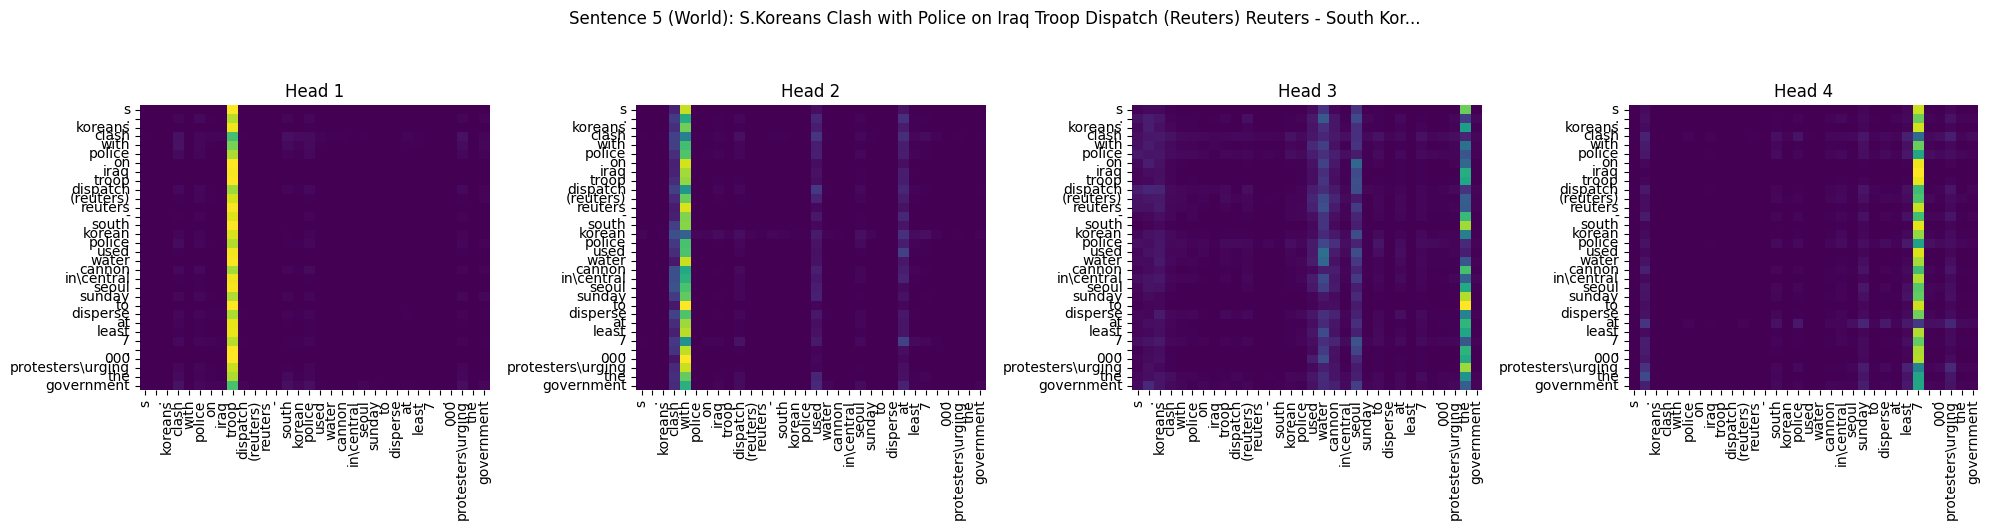

In [ ]:
def plot_attention_heatmaps(model, tokenizer, sentences_with_labels, max_len=32):
    model.eval()
    for idx, (text, label) in enumerate(sentences_with_labels):
        tokens = tokenizer.encode(text, max_len)
        x = torch.tensor([tokens], dtype=torch.long)

        with torch.no_grad():
            _, attn_weights = model(x)

        actual_len = min(len(text.split()), max_len)
        token_words = [tokenizer.id2word[t] for t in tokens[:actual_len]]

        attn_matrix = attn_weights[0, :, :actual_len, :actual_len].numpy()

        fig, axes = plt.subplots(1, model.encoder_block.mha.num_heads, figsize=(20, 5))
        fig.suptitle(f"Sentence {idx+1} ({classes[label]}): {text[:80]}...", y=1.05)
        for h in range(model.encoder_block.mha.num_heads):
            sns.heatmap(attn_matrix[h], xticklabels=token_words, yticklabels=token_words,
                        cmap="viridis", ax=axes[h], cbar=False)
            axes[h].set_title(f"Head {h+1}")
        plt.tight_layout()
        plt.show()

sample_sentences_with_labels = []
for i in range(4):
    sample_text = [dataset['text'][j] for j in range(len(dataset)) if dataset['label'][j] == i][0]
    sample_sentences_with_labels.append((sample_text, i))

second_class_0_sentence = [dataset['text'][j] for j in range(len(dataset)) if dataset['label'][j] == 0][1]
sample_sentences_with_labels.append((second_class_0_sentence, 0))

plot_attention_heatmaps(model, tokenizer, sample_sentences_with_labels)

### Task 5: Causal Masking (Optional)

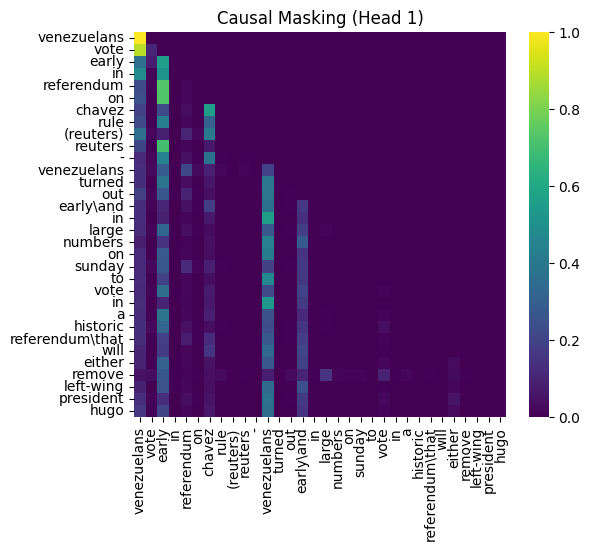

In [ ]:
def get_causal_mask(seq_len):
    mask = torch.tril(torch.ones(seq_len, seq_len))
    return mask

# Use the first sentence from the list defined in the previous cell
test_text = sample_sentences_with_labels[0][0]
tokens = tokenizer.encode(test_text, max_len)
x = torch.tensor([tokens], dtype=torch.long)
actual_len = min(len(test_text.split()), max_len)
token_words = [tokenizer.id2word[t] for t in tokens[:actual_len]]

mask = get_causal_mask(max_len)
with torch.no_grad():
    _, attn_weights_causal = model(x, mask=mask)

causal_matrix = attn_weights_causal[0, 0, :actual_len, :actual_len].numpy()

plt.figure(figsize=(6, 5))
sns.heatmap(causal_matrix, xticklabels=token_words, yticklabels=token_words, cmap="viridis")
plt.title("Causal Masking (Head 1)")
plt.show()

### Task 7: Positional Encoding Visualization

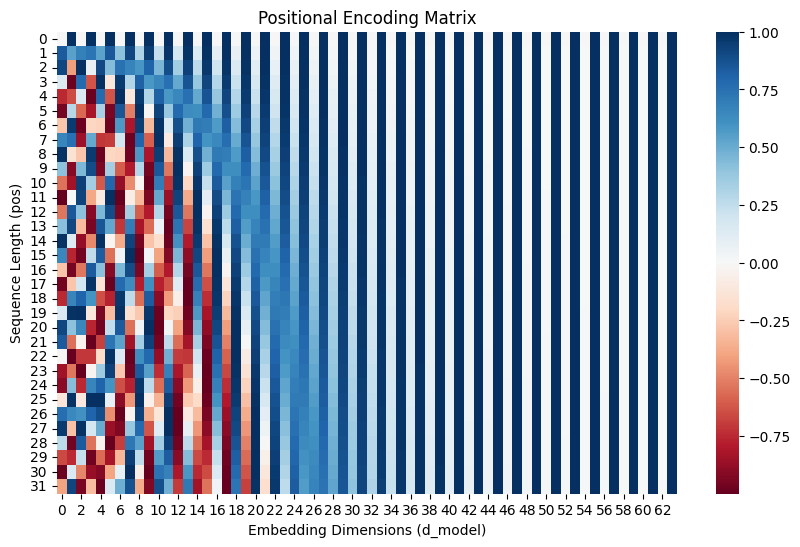

In [ ]:
pe_layer = PositionalEncoding(d_model=64, max_len=32)
pe_matrix = pe_layer.pe[0].numpy()

plt.figure(figsize=(10, 6))
sns.heatmap(pe_matrix, cmap="RdBu")
plt.title("Positional Encoding Matrix")
plt.xlabel("Embedding Dimensions (d_model)")
plt.ylabel("Sequence Length (pos)")
plt.show()


### Ablations

Training 2 heads...
Training No Positional Encoding...
Training No Scaling...


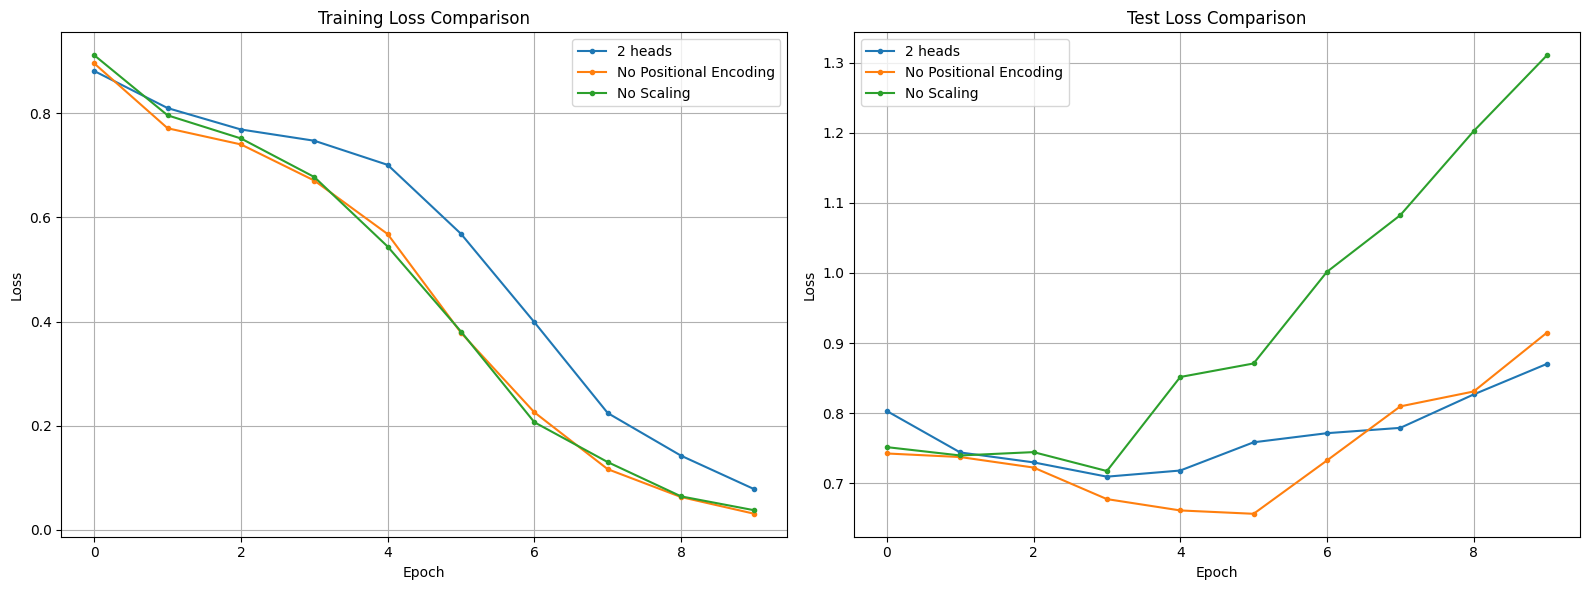

In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(X))
test_size = len(X) - train_size
train_dataset, test_dataset = random_split(TensorDataset(X, Y), [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

def train_and_eval_ablation(model_kwargs, epochs=10):
    params = {'vocab_size': vocab_size, 'd_model': 64, 'num_heads': 2, 'num_classes': 4}
    params.update(model_kwargs)

    model = TransformerEncoder(**params)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        total_train_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            logits, _ = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        train_losses.append(total_train_loss / len(train_loader))

        # Evaluation
        model.eval()
        total_test_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                logits, _ = model(batch_x)
                loss = criterion(logits, batch_y)
                total_test_loss += loss.item()
        test_losses.append(total_test_loss / len(test_loader))

    return train_losses, test_losses

# Define Ablation Studies
configs = [
    ("2 heads", {}),
    ("No Positional Encoding", {'use_pe': False}),
    ("No Scaling", {'use_scaling': False})
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, kwargs in configs:
    print(f"Training {name}...")
    tr_loss, te_loss = train_and_eval_ablation(kwargs)

    ax1.plot(tr_loss, marker='.', label=name)
    ax2.plot(te_loss, marker='.', label=name)

ax1.set_title("Training Loss Comparison")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.set_title("Test Loss Comparison")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Evaluating 1 Head...
Evaluating 2 Heads...
Evaluating 4 Heads...


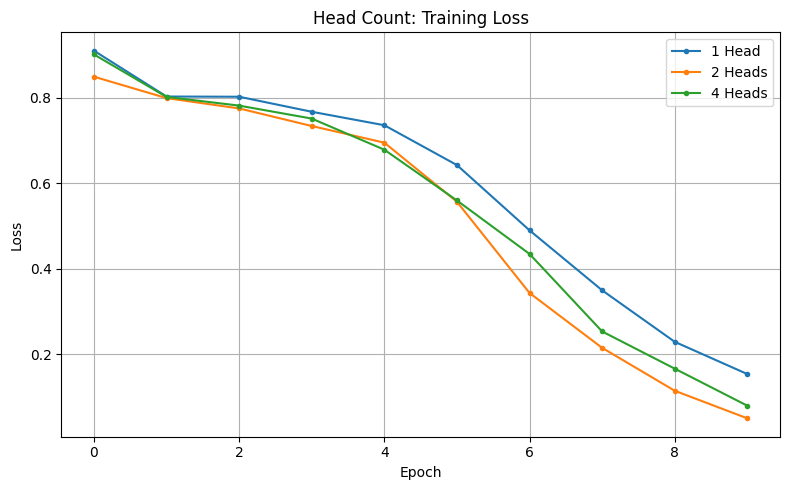

In [ ]:
head_configs = [
    ("1 Head", {'num_heads': 1}),
    ("2 Heads", {'num_heads': 2}),
    ("4 Heads", {'num_heads': 4})
]

plt.figure(figsize=(8, 5))

for name, kwargs in head_configs:
    print(f"Evaluating {name}...")
    tr_loss, _ = train_and_eval_ablation(kwargs)

    plt.plot(tr_loss, marker='.', label=name)

plt.title("Head Count: Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def classify_samples(model, tokenizer, dataset, classes, num_per_class=1):
    model.eval()
    print(f"{'Actual Class':<15} | {'Predicted Class':<15} | {'Text Snippet'}")
    print("-" * 80)

    for i in range(len(classes)):
        # Find samples for this class
        indices = [j for j, label in enumerate(dataset['label']) if label == i][:num_per_class]

        for idx in indices:
            text = dataset['text'][idx]
            tokens = tokenizer.encode(text, max_len=32)
            x = torch.tensor([tokens], dtype=torch.long)

            with torch.no_grad():
                logits, _ = model(x)
                prediction = torch.argmax(logits, dim=1).item()

            actual = classes[i]
            pred = classes[prediction]
            snippet = text[:50].replace('\n', ' ') + "..."
            print(f"{actual:<15} | {pred:<15} | {snippet}")

classify_samples(model, tokenizer, dataset, classes)

Actual Class    | Predicted Class | Text Snippet
--------------------------------------------------------------------------------
World           | World           | Venezuelans Vote Early in Referendum on Chavez Rul...
Sports          | Sports          | Phelps, Thorpe Advance in 200 Freestyle (AP) AP - ...
Business        | Business        | Wall St. Bears Claw Back Into the Black (Reuters) ...
Sci/Tech        | Sci/Tech        | 'Madden,' 'ESPN' Football Score in Different Ways ...


In [ ]:
def calculate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            logits, _ = model(batch_x)
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == batch_y).sum().item()
            total += batch_y.size(0)
    return (correct / total) * 100

train_acc = calculate_accuracy(model, train_loader)
test_acc = calculate_accuracy(model, test_loader)

print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")

Training Accuracy: 100.00%
Test Accuracy: 100.00%
